In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\Export_prz609.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 29406 entries, 0 to 29405
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  29406 non-null  str  
 1   Message  29406 non-null  str  
 2   Status   29406 non-null  str  
dtypes: str(3)
memory usage: 689.3 KB


Odometer

In [3]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date
unit=unit_aux.sort_values('date',ascending=True)

#print(unit)

000101000006  ->  0 60010073.0 0x252514005915740869487064415689003C0E102D00000000EF00000007000061000000FFFFFFFFFFFFFFFFFFFF16800393AE5900000101000006CD8C9044A35197C2ABA455400000001403902783FFFFFF000028FFFFFFFFFF
260601004010  ->  1 58533507.0 0x2525130059D5480869487064415689003C0E102D000000594F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5037D268300260601004010000090439B9A95C2E9E089400000015F03902385FFFFFF0000240000FFFFFF
260601014009  ->  2 58533507.0 0x2525130059D5490869487064415689003C0E102D0000005D5000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5037D268300260601014009000090439B9A95C2E9E089400000015F03902384FFFFFF0000230000FFFFFF
260601024010  ->  3 58533507.0 0x2525130059D54A0869487064415689003C0E102D000000605100000007000020000000FFFFFFFFFFFFFFFFFFFF00D5037D268300260601024010000090439B9A95C2E9E089400000015F03902384FFFFFF0000220000FFFFFF
260601034010  ->  4 58533507.0 0x2525130059D54B0869487064415689003C0E102D000000644F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5037D268300260601034010000

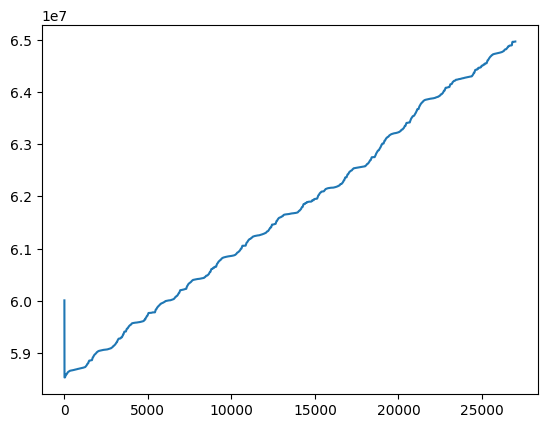

In [4]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,4])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],' -> ',x_axis[i],y_axis[i],raw_data_[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Speed']=speed
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

#print(unit)

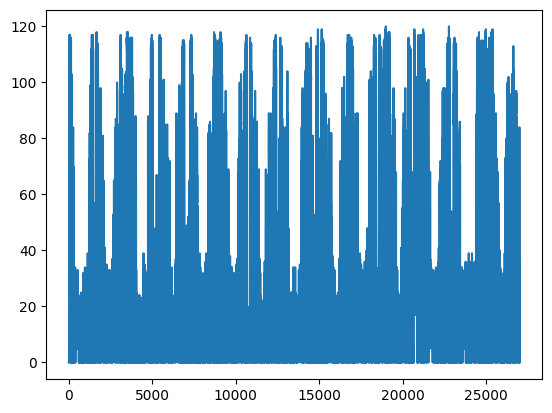

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,4])

plt.plot(x_axis,y_axis)

Mileage report from Ignition 01-06-2026 to 01-07-2026 because Ignition only let me download in this period.

In [7]:
mr=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\mileageReport_prz609.csv',sep=',')
mr.info()

<class 'pandas.DataFrame'>
RangeIndex: 15757 entries, 0 to 15756
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unit                 15757 non-null  str    
 1   Time/Date (UTC-5)    15757 non-null  str    
 2   Address              15757 non-null  str    
 3   Distance (km)        15757 non-null  float64
 4   Total Distance (km)  15757 non-null  float64
 5   Odometer             15757 non-null  float64
 6   Driver               0 non-null      float64
dtypes: float64(4), str(3)
memory usage: 861.8 KB


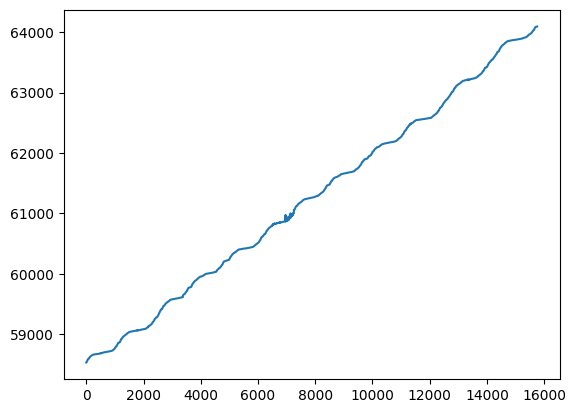

In [8]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,mr.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(mr.iloc[i,5]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])

#plt.xlim(6950,7150)
plt.plot(x_axis,y_axis)

In [9]:
for i in range(6950,7150):
    print(mr.iloc[i,1],' -> ',mr.iloc[i,5],' -> ', i)


06/13/2026 3:25 PM  ->  60869.83  ->  6950
06/13/2026 3:27 PM  ->  60869.84  ->  6951
06/13/2026 3:27 PM  ->  60869.89  ->  6952
06/13/2026 3:27 PM  ->  60870.1  ->  6953
06/13/2026 3:27 PM  ->  60870.92  ->  6954
06/13/2026 3:28 PM  ->  60870.29  ->  6955
06/13/2026 3:28 PM  ->  60871.34  ->  6956
06/13/2026 3:31 PM  ->  60871.34  ->  6957
06/13/2026 3:32 PM  ->  60878.03  ->  6958
06/13/2026 3:32 PM  ->  60871.37  ->  6959
06/13/2026 3:32 PM  ->  60871.4  ->  6960
06/13/2026 3:32 PM  ->  60871.4  ->  6961
06/13/2026 3:32 PM  ->  60871.42  ->  6962
06/13/2026 3:32 PM  ->  60975.72  ->  6963
06/13/2026 3:32 PM  ->  60871.45  ->  6964
06/13/2026 3:32 PM  ->  60871.56  ->  6965
06/13/2026 3:33 PM  ->  60871.61  ->  6966
06/13/2026 3:33 PM  ->  60911.15  ->  6967
06/13/2026 3:33 PM  ->  60871.64  ->  6968
06/13/2026 3:33 PM  ->  60871.79  ->  6969
06/13/2026 3:34 PM  ->  60872.14  ->  6970
06/13/2026 3:34 PM  ->  60872.14  ->  6971
06/13/2026 3:36 PM  ->  60872.16  ->  6972
06/13/2026 3:3

Activity report from Ignition 01-06-2026 to 01-07-2026 because Ignition only let me download in this period.

In [10]:
ar=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\Activity Report prz609.csv',sep=',')

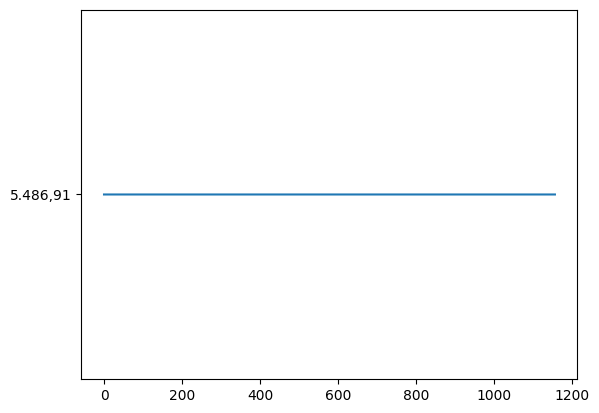

In [11]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,ar.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(ar.iloc[i,11])
    x_axis.append(i)
    date.append(unit.iloc[i,1])

#plt.xlim(6950,7150)
plt.plot(x_axis,y_axis)